# 01 — LLM Fundamentals

**AI Engineer — hands-on session**

Everything here uses the `openai` library. Nothing else.

> **An LLM is a stateless function: text in, text out.**
> Everything else — memory, tools, RAG — is scaffolding we build around it.

---

### Before you start

You need an API key from at least one of these:

| Secret | Where to get it |
|---|---|
| `OPENROUTER_API_KEY` | https://openrouter.ai/keys |
| `GROQ_API_KEY` | https://console.groq.com/keys *(optional)* |

**In the Colab web UI:** open the **🔑 Secrets** panel (key icon, left sidebar), add the secret and enable *Notebook access*.

**Anywhere else** (VS Code, local Jupyter): set it as an environment variable, or just run the cell — it will prompt you for the key.

In [ ]:
%pip install -q --upgrade openai tiktoken "gradio>=5"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 48.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 28.0 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 6.1 MB/s eta 0:00:00


> ⚠️ Colab ships an old Gradio. If section 7 raises a `TypeError`, use **Runtime → Restart session** and run the notebook again.

In [3]:
import getpass
import json
import os
import urllib.request

HELPERS_URL = "https://raw.githubusercontent.com/ingmiguelfernando/AIExperiment/main/helpers.py"

# Plotting code lives in helpers.py so it does not get in the way here.
if not os.path.exists("helpers.py"):
    urllib.request.urlretrieve(HELPERS_URL, "helpers.py")

import helpers

### One library, any provider

The `openai` package is not tied to OpenAI. Any provider that speaks the same protocol works by changing `base_url`.

Switch `PROVIDER` below to prove it.

In [ ]:
from openai import OpenAI

PROVIDERS = {
    "openrouter": {
        "base_url": "https://openrouter.ai/api/v1",
        "secret": "OPENROUTER_API_KEY",
        "model": "google/gemma-4-31b-it:free",
        # "model": "nvidia/nemotron-3-super-120b-a12b:free",
        # "model": "openrouter/free",  # router: picks a different model on every call
    },
    "groq": {
        "base_url": "https://api.groq.com/openai/v1",
        "secret": "GROQ_API_KEY",
        "model": "openai/gpt-oss-20b",
        # "model": "llama-3.3-70b-versatile",
    },
}

PROVIDER = "openrouter"


def get_secret(name):
    """Colab Secrets if available, then an environment variable, then a prompt."""
    try:
        from google.colab import userdata  # type: ignore

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        # Secrets are unreachable when the notebook is driven from VS Code.
        pass

    return os.environ.get(name) or getpass.getpass(f"{name}: ")


settings = PROVIDERS[PROVIDER]
MODEL = settings["model"]
client = OpenAI(api_key=get_secret(settings["secret"]), base_url=settings["base_url"])

print(f"Provider : {PROVIDER}")
print(f"Model    : {MODEL}")

Provider : openrouter
Model    : openrouter/free


---
## 1. The simplest possible call

A list of messages goes in, one message comes out. That is the entire API.

In [5]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a concise assistant."},
        {"role": "user", "content": "In one sentence, what is the capital of New Zealand?"},
    ],
)

print(response.choices[0].message.content)

The capital of New Zealand is Wellington.


### What it actually returns

The response is more than text. Look at `usage`: **that is what you pay for**.

In [6]:
print("Model         :", response.model)
print("Finish reason :", response.choices[0].finish_reason)
print("Input tokens  :", response.usage.prompt_tokens)
print("Output tokens :", response.usage.completion_tokens)
print("Total tokens  :", response.usage.total_tokens)

Model         : nvidia/nemotron-3-ultra-550b-a55b:free
Finish reason : stop
Input tokens  : 34
Output tokens : 30
Total tokens  : 64


---
## 2. So what is a token?

The model never sees letters, and it never sees words. Text is chopped into **tokens** — frequent chunks of characters — and each one becomes a number.

Rough rule for English: **1 token ≈ 4 characters ≈ ¾ of a word**.

In [7]:
import tiktoken

encoder = tiktoken.get_encoding("o200k_base")

helpers.show_tokens("Wellington is the capital of New Zealand.", encoder)

In [8]:
print(encoder.encode("Wellington is the capital of New Zealand."))

[54, 78145, 382, 290, 9029, 328, 2036, 24044, 13]


### Not every text costs the same

Watch what happens with another language, with numbers, and with an unusual word.

In [9]:
helpers.show_tokens("Wellington es la capital de Nueva Zelanda.", encoder)
helpers.show_tokens("Invoice 4829175 total: $1,284.50", encoder)
helpers.show_tokens("antidisestablishmentarianism", encoder)

> The same sentence in Spanish costs more tokens than in English. That is a real cost difference, and it is why non-English apps are more expensive to run.

Try your own text at https://platform.openai.com/tokenizer

### Why this explains a famous failure

Ask a model how many times the letter **r** appears in *strawberry*. Many get it wrong. Here is why:

In [10]:
helpers.show_tokens("strawberry", encoder)

answer = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "How many times does the letter r appear in strawberry? Answer with a number only."}],
)

print("The model says:", answer.choices[0].message.content)

The model says: 3


> The model does not see `s-t-r-a-w-b-e-r-r-y`. It sees a couple of chunks. Asking it to count letters is like asking you to count the brush strokes in a printed word.
>
> Newer models often get this right — not because they learned to see letters, but because the question became common enough in training data.

---
## 3. Streaming

The model produces **one token at a time**. Streaming does not make it faster: it just lets us watch it happen.

In [11]:
stream = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Describe New Zealand in 3 short bullet points."}],
    stream=True,
)

for chunk in stream:
    piece = chunk.choices[0].delta.content
    if piece:
        print(piece, end="")

*   **Stunning & Diverse Landscapes:** Dramatic fjords, active volcanoes, alpine mountains, golden beaches, and rolling green hills packed into a landmass roughly the size of Colorado or the UK.
*   **Unique Biodiversity:** A "land of birds" with no native land mammals (except bats), famous for the flightless kiwi, the alpine kea parrot, and ancient reptile species like the tuatara.
*   **Māori Culture & Modern Identity:** A bicultural foundation defined by the Treaty of Waitangi (Te Tiriti o Waitangi), blending rich Māori heritage (language, haka, art) with a progressive, outdoor-loving, multicultural society.

---
## 4. Where the next token comes from

At every step the model scores **every** token in its vocabulary. Those scores become probabilities, and one token is sampled.

Suppose the model has just read *"The capital of New Zealand is"* and produced these scores:

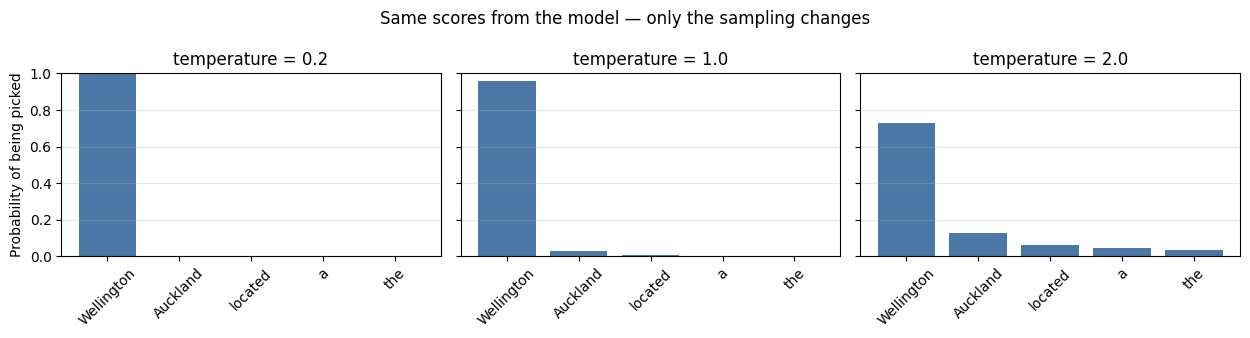

In [12]:
candidates = ["Wellington", "Auckland", "located", "a", "the"]
scores = [8.0, 4.5, 3.0, 2.5, 2.0]

helpers.plot_temperature(candidates, scores, temperatures=(0.2, 1.0, 2.0))

**The model's scores never changed.** Only how we sample from them did:

- **Low temperature** → the gap is exaggerated, the top token wins nearly always. Repeatable, predictable, boring.
- **Temperature 1** → the distribution as the model produced it.
- **High temperature** → the gap is flattened, unlikely tokens get a real chance. Creative, or nonsense.

This is the whole trick. Now let's see it on a live call:

In [13]:
PROMPT = "Invent a name for a coffee shop in Wellington. Reply with the name only."

for temperature in (0.0, 0.0, 1.6, 1.6):
    result = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": PROMPT}],
        temperature=temperature,
        max_tokens=200,
    )
    text = (result.choices[0].message.content or "").strip()
    print(f"temperature={temperature} -> {text or '(empty response)'}")

temperature=0.0 -> The Southerly
temperature=0.0 -> (empty response)
temperature=1.6 -> (empty response)
temperature=1.6 -> Windy Bean Coffee


> The first two should match, the last two should not.
>
> Two things can spoil it: GPU batching adds a little non-determinism even at temperature 0, and some models ignore the parameter entirely.
>
> ⚠️ It also breaks completely with `openrouter/free`, because that is a **router**, not a model — it forwards each call to whichever free model is available at that moment. Same temperature, different model, different answer.

---
## 5. A small experiment

Two calls. Let's start by telling it something about ourselves.

In [14]:
first = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "My name is Miguel and I'm from Colombia."}],
)

print(first.choices[0].message.content)

¡Hola, Miguel! ¡Mucho gusto! 🇨🇴

¿Cómo estás? ¿En qué te puedo ayudar hoy?


### ❓ Before running the next cell — what will it answer?

In [15]:
second = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "What is my name?"}],
)

print(second.choices[0].message.content)

I don't have your name on record, as I don't retain personal information from previous conversations. If you'd like me to address you by name, please let me know what you'd prefer to be called! How can I assist you today?


It has no idea. **This is not a bug: it is the design.** Every call is independent, like calling a pure function.

The fix? There is no trick. We send everything again:

In [16]:
conversation = [
    {"role": "user", "content": "My name is Miguel and I'm from Colombia."},
    {"role": "assistant", "content": first.choices[0].message.content},
    {"role": "user", "content": "What is my name?"},
]

third = client.chat.completions.create(model=MODEL, messages=conversation)

print(third.choices[0].message.content)



Your name is Miguel. It's nice to meet you!


> ### 💡 The key idea
> **"Chat" does not exist.** It is a Python list we append to and resend in full on every turn.
>
> What ChatGPT calls *memory* is this loop: store the history, resend it.

Keep this in mind for when we get to RAG.

---
## 6. The cost of remembering

If we resend the whole conversation every turn, then on turn *n* we send *n* messages. The total does not grow in a straight line — it grows **quadratically** (≈ n²/2).

That is why long conversations get slow and expensive, and why a *context window* exists at all.

In [17]:
turns = [
    "Give me one fun fact about New Zealand.",
    "Another one, please.",
    "One more, different topic.",
    "Another one.",
    "Last one.",
]

messages = [{"role": "system", "content": "Reply in exactly one short sentence."}]
sent_per_turn, cumulative = [], []
total = 0

for turn in turns:
    messages.append({"role": "user", "content": turn})
    result = client.chat.completions.create(model=MODEL, messages=messages)
    messages.append({"role": "assistant", "content": result.choices[0].message.content})

    total += result.usage.total_tokens
    sent_per_turn.append(result.usage.prompt_tokens)
    cumulative.append(total)
    print(f"Turn {len(cumulative)}: sent {result.usage.prompt_tokens:>4} | cumulative {total:>5}")

Turn 1: sent   32 | cumulative    63
Turn 2: sent   77 | cumulative   164
Turn 3: sent  124 | cumulative   540
Turn 4: sent  122 | cumulative  1404
Turn 5: sent  231 | cumulative  1851


In [ ]:
helpers.plot_token_growth(sent_per_turn, cumulative)

---
## 7. Gradio: the same loop, with a UI

`gr.ChatInterface` keeps the history and hands it back to us as `history`. The function below does exactly what we just did by hand: **concatenate the list and resend it**.

In [ ]:
import gradio as gr

if int(gr.__version__.split(".")[0]) < 5:
    raise RuntimeError(
        f"Gradio {gr.__version__} is too old for this cell. Restart the kernel so the "
        "upgraded version is picked up (Colab: Runtime -> Restart session), then run again."
    )

SYSTEM_PROMPT = "You are a helpful assistant. Keep answers short."


def chat(message, history):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}, *history, {"role": "user", "content": message}]

    stream = client.chat.completions.create(model=MODEL, messages=messages, stream=True)

    partial = ""
    for chunk in stream:
        partial += chunk.choices[0].delta.content or ""
        yield partial


gr.ChatInterface(chat, type="messages", title="We are the ones storing the history").launch()

TypeError: ChatInterface.__init__() got an unexpected keyword argument 'type'

---
## 8. Tools: giving the model hands

Our fictional airline **KiwiAir** has a price list. The model cannot possibly know it — the airline does not exist.

First, not every free model supports *function calling*. Let's ask the catalogue instead of guessing:

In [19]:
import requests

catalogue = requests.get("https://openrouter.ai/api/v1/models", timeout=30).json()["data"]

tool_models = sorted(
    model["id"]
    for model in catalogue
    if model["id"].endswith(":free") and "tools" in model.get("supported_parameters", [])
)

print(len(tool_models), "free models that support tools\n")
for model_id in tool_models[:15]:
    print(" -", model_id)

19 free models that support tools

 - cohere/north-mini-code:free
 - dots-studio/dots-3-note-preview:free
 - google/gemma-4-26b-a4b-it:free
 - google/gemma-4-31b-it:free
 - inclusionai/ling-3.0-flash-fin:free
 - inclusionai/ling-3.0-flash-sante:free
 - inclusionai/ling-3.0-flash-vl:free
 - liquid/lfm-2.5-2.6b:free
 - nex-agi/nex-n2.5-mini:free
 - nex-agi/nex-n2.5-pro:free
 - nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
 - nvidia/nemotron-3-super-120b-a12b:free
 - nvidia/nemotron-3-ultra-550b-a55b:free
 - nvidia/nemotron-3.5-lightning:free
 - poolside/laguna-s-2.1:free


In [ ]:
# Free model slugs come and go, so pick from what the catalogue reported just now.
PREFERRED = [
    "google/gemma-4-31b-it:free",
    "nvidia/nemotron-3-super-120b-a12b:free",
    "google/gemma-4-26b-a4b-it:free",
]

TOOL_MODEL = next((name for name in PREFERRED if name in tool_models), tool_models[0])

print("Tool demo will use:", TOOL_MODEL)

Tool demo will use: meta-llama/llama-3.3-70b-instruct:free


### The tool is an ordinary Python function

No AI in here. A dictionary and a lookup — that is all a "tool" ever is.

In [21]:
TICKET_PRICES = {
    "auckland": 189,
    "christchurch": 159,
    "queenstown": 249,
    "rotorua": 129,
}


def get_ticket_price(destination_city: str) -> dict:
    print(f"   [our code ran] get_ticket_price({destination_city!r})")
    price = TICKET_PRICES.get(destination_city.lower())
    return {"destination_city": destination_city, "price_nzd": price or "unknown"}


get_ticket_price("Queenstown")

   [our code ran] get_ticket_price('Queenstown')


{'destination_city': 'Queenstown', 'price_nzd': 249}

### We describe it to the model

This schema is just text that gets added to the prompt. The model never receives the function — only a description of it.

In [22]:
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_ticket_price",
            "description": "Get the price of a KiwiAir return ticket to a destination city.",
            "parameters": {
                "type": "object",
                "properties": {
                    "destination_city": {
                        "type": "string",
                        "description": "The city the customer wants to fly to",
                    }
                },
                "required": ["destination_city"],
            },
        },
    }
]

messages = [{"role": "user", "content": "How much is a KiwiAir ticket to Queenstown?"}]

first_pass = client.chat.completions.create(model=TOOL_MODEL, messages=messages, tools=TOOLS)
reply = first_pass.choices[0].message

print("Text       :", repr(reply.content))
print("Tool calls :", reply.tool_calls)

NotFoundError: Error code: 404 - {'error': {'message': 'This model is unavailable for free. The paid version is available now - use this slug instead: meta-llama/llama-3.3-70b-instruct', 'code': 404}, 'user_id': 'user_3F1N81BzCOR6D5BErtSiTKPFsO3'}

> ### 💡 The most misunderstood part of all of this
> **Nothing was executed.** The model returned JSON *asking* us to run a function.
>
> Notice there was no `[our code ran]` line above. The model has no hands — it only writes text.

### So we run it, and hand the result back

In [23]:
AVAILABLE_TOOLS = {"get_ticket_price": get_ticket_price}

messages.append(reply.model_dump(exclude_none=True))

for call in reply.tool_calls or []:
    arguments = json.loads(call.function.arguments)
    observation = AVAILABLE_TOOLS[call.function.name](**arguments)

    messages.append({"role": "tool", "tool_call_id": call.id, "content": json.dumps(observation)})

second_pass = client.chat.completions.create(model=TOOL_MODEL, messages=messages, tools=TOOLS)
print("\n" + second_pass.choices[0].message.content)

NameError: name 'reply' is not defined

### The whole loop, in four steps

1. We send the question **and the menu of available functions**
2. The model replies with JSON: *"call `get_ticket_price` with `Queenstown`"*
3. **Our** code runs the function and appends the result to the message list
4. We call the model again — now the answer is in its context

Every "AI agent" you have heard about is this loop, repeated until the model stops asking for tools.

In [25]:
for message in messages:
    print(json.dumps(message, indent=2)[:400])
    print("-" * 60)

{
  "role": "user",
  "content": "How much is a KiwiAir ticket to Queenstown?"
}
------------------------------------------------------------


### Plan B: the same idea without `tools`

If a model does not support function calling, we can just ask for JSON in the prompt. It is more fragile, but it shows that **`tools` is syntactic sugar over "reply in this format"**.

In [26]:
INSTRUCTIONS = (
    "You can use one function: get_ticket_price(destination_city).\n"
    'If the question needs it, reply ONLY with: {"tool": "get_ticket_price", "destination_city": "<city>"}\n'
    "Otherwise reply with plain text."
)
QUESTION = "How much does it cost to fly to Rotorua?"

raw = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": INSTRUCTIONS},
        {"role": "user", "content": QUESTION},
    ],
    temperature=0,
).choices[0].message.content.strip()

print("The model replied:", raw)

try:
    request = json.loads(raw)
except json.JSONDecodeError:
    print("\nNot valid JSON — which is exactly the fragility of doing it by hand.")
else:
    observation = get_ticket_price(request["destination_city"])

    final = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": QUESTION},
            {"role": "user", "content": f"Price data: {json.dumps(observation)}. Answer in one sentence."},
        ],
    )
    print("\n" + final.choices[0].message.content)

The model replied: {"tool":"get_ticket_price","destination_city":"Rotorua"}
   [our code ran] get_ticket_price('Rotorua')

The flight to Rotorua costs 129 New Zealand Dollars (NZD) according to the current price data.


---
## Recap

| What it looks like | What it really is |
|---|---|
| The model reads my words | It reads token numbers, and cannot see letters |
| The chatbot remembers me | We resend the full list every single turn |
| The model is creative | It samples from a probability distribution |
| The model looked something up | It returned JSON and *our* code made the call |

It all comes down to **what text we put in the prompt**.

Which is the next problem: context is finite, and you pay for it by the token. We cannot paste a company's entire documentation into every question.

➡️ **Continues in `02_rag.ipynb`**